# This documents the evaluation for the Standards release to render it reproducible:
- Data released as part of LA-UR-25-29295.
- Journal article: https://doi.org/10.1051/epjn/2025061 

In [2]:
from numpy import array, loadtxt, zeros, shape,arange, sqrt, exp, ones, sinh, interp
import importlib
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
%matplotlib inline 
import os

In [3]:
homedir = os.getcwd() +'/'

In [4]:
cd ../../../src

/Users/dneudecker/Documents/Codes/ARIADNE-github/src


In [5]:
import EvaluateGLSPFNS as Eval
importlib.reload(Eval)

<module 'EvaluateGLSPFNS' from '/Users/dneudecker/Documents/Codes/ARIADNE-github/src/EvaluateGLSPFNS.py'>

In [6]:
def norm(E,PFNSeval,Eexp,PFNSexp):
    from numpy import interp
    
    DataMod_int = array(interp(Eexp,E,PFNSeval))

    n1 = 0; n2 = 0
    for index1 in arange(0,max(shape(Eexp))-1):
        n1 = n1+0.5*(DataMod_int[index1]+DataMod_int[index1+1])*(Eexp[index1+1]-Eexp[index1])
        n2 = n2+0.5*(PFNSexp[index1]+PFNSexp[index1+1])*(Eexp[index1+1]-Eexp[index1])
    print(n1/n2)
    
    return (n1/n2)

## Evaluate for final standards release:
- Prior: uninformative prior based on previous Standard.
- PPP: on with 10 iterations.
- database: DataBase_ForEvaluation_Chalupka1outlyingdata_Maerten60degonlyLA-UR-25-29295_inputforSTANDARD.json
- Chi^2: 0.4193009896802381

------------------------------------
Experiments included in evaluation:
['Blinov', 'Vitenko', 'Tuz', 'Kazarinov', 'Krisyuk']
['Blinov', 'Vitenko', 'Yurevich']
['Blinov', 'Vitenko', 'Yurevich']
['Blinov', 'Vitenko', 'Yurevich']
['Blinov', 'Vitenko', 'Yurevich']
['Bottger', 'Klein', 'Chalupka', 'Strohmaier']
['Boldeman', 'Clancy', 'Culley']
['Boytsov', 'Starostov']
['Boytsov', 'Starostov']
['Boytsov', 'Starostov']
['A.Chalupka', 'L.Malek', 'S.Tagesen', 'R.Boettger']
['A.Lajtai', 'P.P.Dyachenko', 'V.N.Kononov', 'E.A.Seregina']
['N.V.Kornilov']
['Maerten', 'Richter', 'Seeliger', 'Fromm', 'Boettger', 'Klein']
['Poenitz', 'Tamura']
------------------------------------

 All experimental data within prior grid.
-------------------------------------------
PPP execution, deviation of previous iteration from current iteration prior (should converge with number of iterations): [1.02198727 1.00748492 0.99746431 0.98765301 0.99299157 1.00975536
 0.98636672 0.97529378 0.9763116  0.98512413 0.995696

['/Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Cf-252/PFNS_EvaluationFinalStandardEvaluationForPreservation/Eval_MvUncCf-2520,fnubar-promptGLS.dat',
 '/Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Cf-252/PFNS_EvaluationFinalStandardEvaluationForPreservation/Eval_CorCf-2520,fnubar-promptGLS.dat']

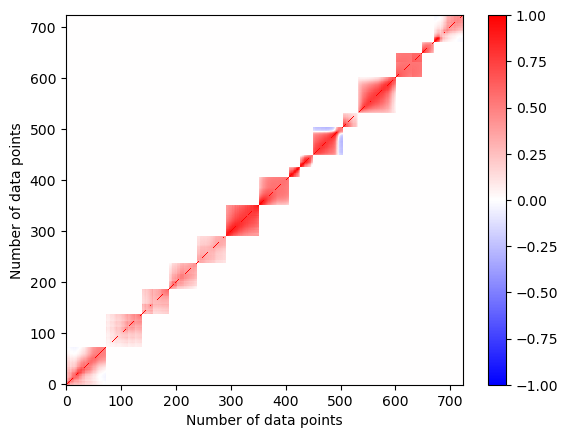

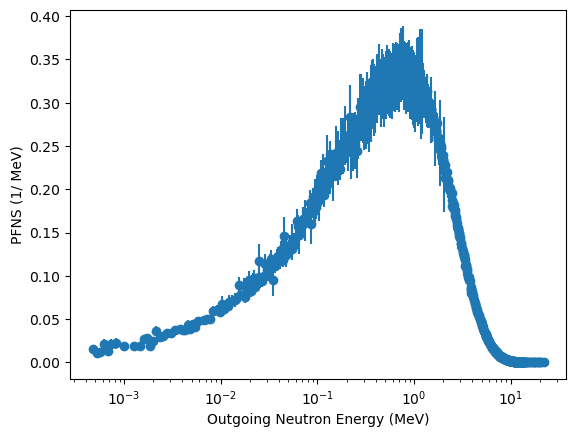

In [8]:
Data = homedir+'DataBase_ForEvaluation_Chalupka1outlyingdata_Maerten60degonlyLA-UR-25-29295_inputforSTANDARD.json'
ExpInput = {'Code':"ARIADNE",'ReadOption':'json',\
              'Data':Data}
PriorInput = {'general_info': {'name': 'VIII0_noninformative',\
                               'isotope': array(['Cf-252']),\
                              'quantity': array(['nubar-prompt']), 'reaction':  array(['0,f'])},\
              'Data':{'mv':array([homedir+'PriorMVCf252PFNS_extendedgrid.dat']),\
              'cor':array([homedir+'PriorCorCf252PFNS_extendedgrid.dat'])}}


Eval.Evaluate(ExpInput,PriorInput,homedir,CommonGrid=False,PPPCorrection=True,Plot=False,MaxwRatioEval=False,LogEval=False,OutputFormat="ARIADNEtxt")



In [9]:
data = loadtxt(homedir+'Eval_MvUncCf-2520,fnubar-promptGLS.dat',skiprows=2)
E = data[:,0]
PFNSeval = data[:,1]
PFNSevalunc = data[:,2]

data = loadtxt(homedir+'Eval_MvUncCf-2520,fnubar-promptGLS__Maerten60degonlyChalupka1datapointsrejectLA-UR-25-29295_finalacceptedSTANDARD.txt',skiprows=2)
E = data[:,0]
PFNSeval_comp = data[:,1]
PFNSevalunc_comp = data[:,2]

In [10]:
def maxwt(E,T):
    pi = 3.14159265359
    
    maxwt = zeros(max(shape(E)),dtype=float)
    for index in arange(0,max(shape(E))):
        maxwt[index] = sqrt(E[index])*exp(-E[index]/T)*(2./sqrt(pi)/sqrt(T)/T)
                     
    return maxwt

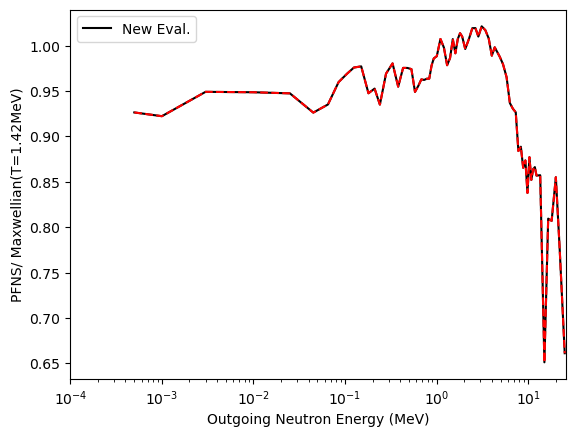

In [11]:
a = 0.0001
b = 26.
plt.figure(2)
#plt.ylim([0.6,1.2])
plt.xlabel('Outgoing Neutron Energy (MeV)')
plt.ylabel('PFNS/ Maxwellian(T=1.42MeV)')
plt.semilogx(E,PFNSeval/maxwt(E,1.42),'k')
plt.semilogx(E,PFNSeval_comp/maxwt(E,1.42),'r--')
plt.xlim([a,b])
plt.legend(['New Eval.'],loc=2)
plt.show()

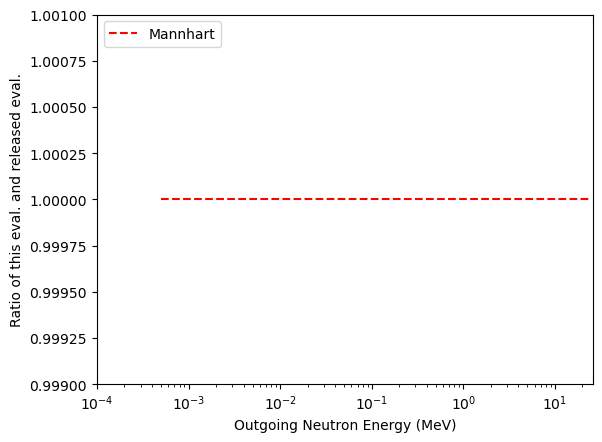

In [12]:
a = 0.0001
b = 26.
plt.figure(2)
plt.ylim([0.999,1.001])
plt.xlabel('Outgoing Neutron Energy (MeV)')
plt.ylabel('Ratio of this eval. and released eval.')
plt.semilogx(E,PFNSeval/PFNSeval_comp,'r--')
plt.xlim([a,b])
plt.legend(['Mannhart','New Eval.'],loc=2)
plt.show()